In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import boxcox

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.model_selection import RepeatedKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

from itertools import product

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


# TEST CODE

In [3]:
class GROUP_INFO():
    def __init__(self,
        near_zero_sites, high_agb_sites,
        near_zero_plots, high_agb_plots,
        groups, cv
    ):
        self.near_zero_sites = near_zero_sites
        self.high_agb_sites = high_agb_sites
        self.near_zero_plots = near_zero_plots
        self.high_agb_plots = high_agb_plots
        self.groups = groups
        self.cv = cv

class BASE:
    def __init__(
        self,
        X_in, y_in, features,
        is_groups, group_info,
    ):
        self.y = y_in
        self.features = features
        self.near_zero_sites = group_info.near_zero_sites
        self.high_agb_sites = group_info.high_agb_sites
        self.near_zero_plots = group_info.near_zero_plots
        self.high_agb_plots = group_info.high_agb_plots
        self.groups = group_info.groups
        self.cv = group_info.cv
        self.is_groups = is_groups
        self.results = {}

        assert features
        self.X = X_in[features]

        categorical_cols = get_categorical_cols(self.X)
        if categorical_cols:
            self.X = pd.get_dummies(self.X, columns=categorical_cols, dtype=int)

            
    def evaluate(self, label):
        fold_sites = None

        if self.is_groups:
            fold_sites = self.results.get("fold_sites")

            verdict = evaluate_experiment(
                label=label,
                results=self.results,
                fold_sites=fold_sites,
                near_zero_sites=self.near_zero_sites,
                high_agb_sites=self.high_agb_sites
            )
        else:
            verdict = evaluate_experiment(
                label=label,
                results=self.results,
                fold_sites=None,
                near_zero_sites=self.near_zero_plots,
                high_agb_sites=self.high_agb_plots
            )

        self.results["verdict"] = verdict

class R_FOREST(BASE):
    def __init__(
        self,
        X_in, y_in, features,
        is_groups, group_info,
        is_grid
    ):
        super().__init__(X_in, y_in, features, is_groups, group_info)
        self.is_grid = is_grid

    def run(self, label):
        if self.is_groups:
            self.results = randomForest_groups(
                self.X,
                self.y,
                self.cv,
                self.groups,
                label,
                grid=self.is_grid,
                display=True
            )
        else:
            self.results = randomForest_regular(
                self.X,
                self.y,
                self.cv,
                label,
                grid=self.is_grid,
                display=True
            )

        self.evaluate(label)

        if self.is_groups:
            show_importances(self.results)

class LIN_REG(BASE):
    def __init__(
        self,
        X_in, y_in, features,
        model_type,
        is_groups, group_info
    ):
        super().__init__(X_in, y_in, features, is_groups, group_info)

        self.model_type = model_type
    def set_model(self, model_type):
        self.model_type = model_type

    def run(self, label):
        if self.is_groups:
            self.results = linear_reg_groups(self.model_type,
                                             self.X, self.y,
                                             self.cv, self.groups,
                                             label
            )
        else:
            self.results = linear_reg_regular(self.model_type,
                                              self.X, self.y,
                                              self.cv,
                                              label)

        self.evaluate(label)

# DOWNLOAD SENTINEL-AGB DATA

In [4]:
SENTINEL_DATA_CSV        = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_SENTINEL_CANOPY.csv"
#SENINEL_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_VAL_EO_SENTINEL.csv"

sentinel_df = pd.read_csv(SENTINEL_DATA_CSV)
print(sentinel_df.shape)
sentinel_df.columns

(8774, 34)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'capture_start',
       'capture_end', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2',
       'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'cloud_threshold_used',
       'simard_height_m', 'tandemx_height_m'],
      dtype='object')

In [5]:
assert len(sentinel_df["simard_height_m"].head())
assert len(sentinel_df["tandemx_height_m"].head())

In [6]:
sentinel_df['dataset'].unique()

array(['ElSalvador', 'Panama-Chirqui_2', 'CostaRica-Nicoya',
       'CostaRica-Sierpe', 'Belige', 'Panama-Chirqui_1',
       'Honduras-Blanca', 'Brazil-Mangue', 'Brazil-Furo_Do_Chato',
       'Brazil-Manguezal', 'Brazil-Maruipe', 'Brazil-AcarauBoca',
       'Brazil-BocaGrande', 'Brazil-Barreto', 'Brazil-Salinas',
       'Brazil-FuroGrande', 'Brazil-Caetano'], dtype=object)

### Select features

In [7]:
non_feature_cols = [
    #'plant_AGB_kg',        # Target variable
    'dataset',             # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
    'diameter',            # Allometric
    'height',               # Allometric
    'cloud_threshold_used'
]
sentinel_bands = [
    'Blue', 'Green', 'Red'
]
sentinel_indices = [
    'NIR', 'SWIR1', 'SWIR2', 'NDVI',
    'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE'
]
useful_categorical = ['plot_id', 'species']
struct_features = ['height']

target = 'plant_AGB_kg'
feature_cols = [c for c in sentinel_df.columns if c not in non_feature_cols]

X_all = sentinel_df[feature_cols]
# Select TANDEMX
X_all = X_all.rename({'tandemx_height_m': 'height'}, axis=1)
X_all = X_all.drop(columns=['simard_height_m'])
y_all = sentinel_df[target]

print(f"Features: {feature_cols}")

Features: ['plot_id', 'species', 'plant_AGB_kg', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'simard_height_m', 'tandemx_height_m']


## DATA PREPROCESSING

In [8]:
null_rows   = X_all[X_all.isnull().any(axis=1)]
total_nulls = X_all.isnull().sum().sum()

print(f"Total NULL count           : {total_nulls}")
print(f"Rows with at least one NULL: {len(null_rows)}")
print(f"Total rows                 : {len(sentinel_df)}")
print(f"Percentage                 : {len(null_rows)/len(sentinel_df)*100:.1f}%")

# NULL count per column for only the affected rows
null_col_counts = null_rows.isnull().sum().sort_values(ascending=False)
print("\nNULL count per column in affected rows:")
print(null_col_counts[null_col_counts > 0])

Total NULL count           : 0
Rows with at least one NULL: 0
Total rows                 : 8774
Percentage                 : 0.0%

NULL count per column in affected rows:
Series([], dtype: int64)


In [9]:
assert not total_nulls
#sentinel_df = handle_null_data(sentinel_df)
#X = X.dropna()
#print(X.shape)
#X.columns

### Find correlations

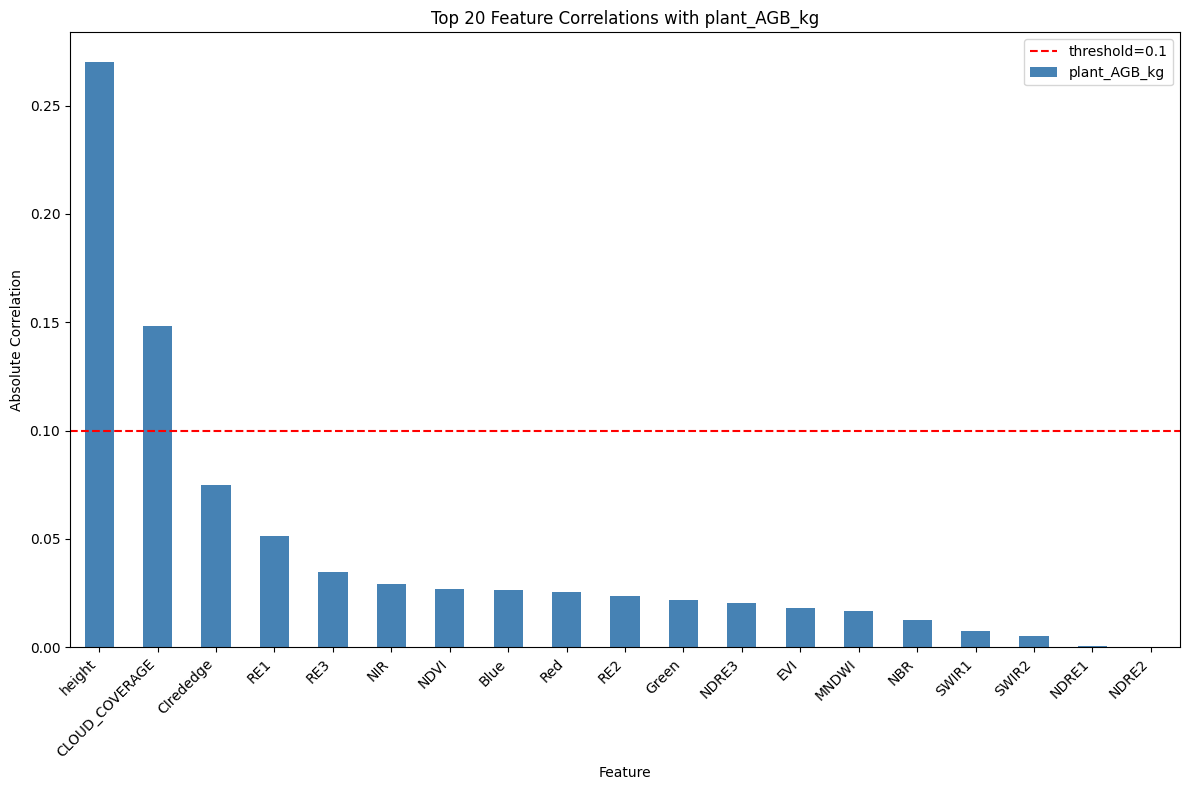

height            0.270332
CLOUD_COVERAGE    0.148244
CIrededge         0.075032
RE1               0.051166
RE3               0.034549
NIR               0.029325
NDVI              0.026838
Blue              0.026532
Red               0.025423
RE2               0.023474
Green             0.021944
NDRE3             0.020353
EVI               0.018145
MNDWI             0.016781
NBR               0.012546
SWIR1             0.007646
SWIR2             0.005075
NDRE1             0.000640
NDRE2             0.000077
Name: plant_AGB_kg, dtype: float64


In [10]:
numerical_cols = get_numerical_cols(X_all)
target_corr = plot_correlation_matrix(X_all[numerical_cols],
                                      X_all['plant_AGB_kg'],
                                      top_n=20)
print(target_corr)

**COMMENTS:**  
Columns with a Pearson correlation coefficient (r) between -0.1 and 0.1 with the target variable are generally considered to have a negligible or very weak relationship.

### Remove Low Variance Features (cols)

#### Is variance threshold valid for sentinel-2 data?

- Sentinel-2 surface reflectance values are typically in the range 0.0 to 0.3.  
 - Their absolute variance is naturally small — not because they carry no information but because their scale is small.  
 - A feature with values ranging from 0.05 to 0.25 has variance of ~0.003, which falls below the 0.01 threshold, but the variation within that range is meaningful for AGB prediction.  
 - VarianceThreshold is designed for features with near-identical values across all rows — like a binary column that is always 0.  
 - It is not appropriate for bounded continuous features like reflectance values.

### Remove Features With Weak Correlation to Target

#### Why Pearson correlation is unreliable here?

Pearson correlation measures linear relationship between a feature and the target. 

The above correlation removal process is based on the correlations computed against the original y. But we are going log-transform the target for modeling. 

A feature can have a strong non-linear relationship with AGB that shows up clearly after log transformation but appears weak in linear correlation against raw AGB.  

The experiments (Belige-data-analysis.ipynb) already proved these features are useful.  

### Convert categorical variables to one-hot encoding

# What would actually constitute a good result?
For a model to be trustworthy you would want to see:
 - Grouped CV mean above 0.15
 - Grouped CV std below 0.25
 - No individual grouped CV fold below -0.10
 - Regular CV and grouped CV in the same ballpark — large divergence between them signals leakage
 - Test R² close to grouped CV mean, not far above it
 - Train R² and test R² in the same ballpark — if train R² is much higher than test R², the model is overfitting to the training set even if it passes the other checks. A train R² of 0.55 with a test R² of 0.08 is a red flag regardless of CV scores.
 - RMSE meaningful relative to the AGB range — R² can look acceptable while RMSE is still too large to be useful.    
   If the typical plant weighs 5 kg and RMSE is 16 kg, the model cannot make useful predictions even if R² is positive.   
 - CV fold scores consistent across folds — a high CV mean can hide one very good fold carrying the average.   
   For example, scores of [0.70, 0.40, 0.35, 0.38, 0.42] give a mean of 0.45 which passes your threshold, but that 0.70 is doing all the work.   
   Your std criterion catches some of this but a floor on individual fold scores (similar to your grouped CV fold floor) would make it explicit.

## Threshold for RMSE
There is no universal formula — it depends on what the model output will actually be used for.  

**The most common approach**  
You compute RMSE as a percentage of the mean target value — this is called the Coefficient of Variation of RMSE (CV-RMSE).
cv_rmse = (rmse / y_test.mean()) * 100
print(f"CV-RMSE: {cv_rmse:.1f}%")

A model predicting house prices with RMSE = $50,000 on a mean price of $500,000 is 10% — reasonable.  
The same RMSE on a mean price of $80,000 is 62% — useless.  

For our dataset, if mean AGB is around 10 kg and RMSE is 16 kg, CV-RMSE is 160%.  
That tells you the model's error is larger than the typical value it is trying to predict.

**Determine near_zero_threshold, and high_agb_threshold**  
**near_zero_threshold = 1.0 kg**
 - Any site where the heaviest plant weighs less than 1 kg has near-zero AGB variance.
 - From your data Frenchman Caye (max 0.26 kg) and Shipstern (max 0.94 kg) fall below this.
 - R² is meaningless for these sites as a holdout set.
 - In other words, R² is mathematically unstable when the holdout set has near-zero variance.

**R² is defined as:** 1 - (sum of squared residuals / total sum of squares)
**Total sum of squares is (denominator):** sum of (y - mean(y))²
**Problem:**  
 - When every plant in the holdout site weighs between 0.001 and 0.26 kg, the mean is ~0.03 kg and every value is very close to that mean.
 - This makes the total sum of squares as near-zero.
 - Any prediction error, however small will produce a large negative R² because of the near-zero denominator.

**high_agb_threshold = 100.0 kg**
 - Any site with trees above 100 kg is potentially ecologically distinct from the rest.
 - From your data Channel Caye (max 427 kg) and New River (max 261 kg) fall above this.
 - These are the sites where generalization failure is a genuine concern.

# ENTIRE DATASET

In [11]:
struct_features = ['height']

sentinel_bands  = ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2']
sentinel_indices = ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE']

top_spectral_1  = ['height', 'EVI', 'NIR', 'NBR', 'SWIR1']
top_spectral_2  = ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1']

redband_1       = ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']
redband_2       = ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']

useful_categorical = []# ['plot_id']

target = 'plant_AGB_kg'

features_list = [struct_features, 
                 #useful_categorical + struct_features,
                 
                 sentinel_bands,
                 sentinel_indices,
                 sentinel_bands + sentinel_indices,
                 #useful_categorical + sentinel_bands + sentinel_indices,
                 struct_features + sentinel_bands + sentinel_indices,
                 #useful_categorical + struct_features + sentinel_bands + sentinel_indices,

                 top_spectral_1,
                 top_spectral_2,
                 redband_1,
                 redband_2]

model_list = ["regular", "ridge", "lasso", "elasticnet"]

test_cv = 5
#test_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

Why I dropped "plot_id"?

What plot_id as a feature was doing
When plot_id was included as a feature, the model learned a lookup table. For each plot it saw during training, it memorised the average AGB for that plot and used that as a prediction signal. This is not generalisation — it is memorisation. A new plot the model has never seen gets no benefit from this signal at all.
The earlier Belize experiments with plot_id (experiments 5-8 in the first run) showed this clearly. Test R² was only 0.036 despite the model having 63 features. The model trained on plot identities that do not exist in the test set.


By dropping plot_id as a feature but keeping it for grouping, you have separated two distinct roles:
Grouping — plot_id tells the CV splitter which plants belong together and must be held out as a unit. This prevents leakage. This is correct.
Features — the model now learns only from spectral measurements, height, and species. These are variables that exist for any new plant at any new location.
This is what makes the model deployable.

In [12]:
# Retain the groups/plot_id for splitting the data based on groups.
plot_groups_all = X_all['plot_id'].copy()
site_groups_all = plot_groups_all.map(lambda x: x.rsplit('_', maxsplit=1)[0])

near_zero_sites_all, high_agb_sites_all, near_zero_plots_all, high_agb_plots_all = \
                                get_low_and_high_agb_plots(y_all, plot_groups_all)

grp_all = GROUP_INFO(near_zero_sites_all, high_agb_sites_all,
                     near_zero_plots_all, high_agb_plots_all,
                     groups=plot_groups_all,
                     cv=test_cv)

High-AGB threshold  : 1336.17 kg
Near-zero threshold : 0.000052

Near-zero variance plots:
  Big Creek_1               : log var = 0.000036
  Big Creek_4               : log var = 0.000032

High-AGB plots:
  ACA_Acarau Boca           : max AGB = 1468.1 kg
  Arco_del_Espino_18_1      : max AGB = 1564.3 kg
  Arco_del_Espino_18_3      : max AGB = 2403.6 kg
  Arco_del_Espino_18_6      : max AGB = 2403.6 kg
  BAR_Barreto               : max AGB = 2169.6 kg
  BOC_Boca Grande           : max AGB = 5572.3 kg
  Bordo_del_Chile_23_2      : max AGB = 1542.6 kg
  CAE_Caetano               : max AGB = 7364.1 kg
  Desembocadura_Río_Lempa_1_2 : max AGB = 2520.3 kg
  Desembocadura_Río_Lempa_1_3 : max AGB = 1641.7 kg
  Desembocadura_Río_Lempa_1_4 : max AGB = 1594.4 kg
  Desembocadura_Río_Lempa_1_6 : max AGB = 2739.9 kg
  El R’o_5                  : max AGB = 1371.5 kg
  El R’o_6                  : max AGB = 1421.6 kg
  El_Aguacate_24_1          : max AGB = 1627.4 kg
  El_Plan_de_la_Ceiba_8_1   : max AG

## LINEAR REGRESSION

In [13]:
def lin_experiment(X, y, is_groups, group_info,
                   label, lin_experiments):
    total     = len(features_list) * len(model_list)
    completed = 0

    for (feat_idx, features), (model_type) in product(enumerate(features_list), model_list):
        completed += 1
        print(f"\n[{completed}/{total}]")
        linr = LIN_REG(X, y, features, model_type, is_groups, group_info)
        
        new_label = f"EXPERIMENT-{completed} {label}, Model: {model_type}, Features: {features}"
        linr.run(new_label)
        lin_experiments[new_label] = linr.results
    print(f"\nCompleted: {completed}/{total} experiments")

### Linear regression without groups.

In [ ]:
%run Model_functions.ipynb
lin_all_no_groups = {}

lin_experiment(X_all, y_all,
               is_groups=True, group_info=grp_all,
               label="No groups",
               lin_experiments=lin_all_no_groups)

# 1st-EXPERIMENT: ENTIRE DATA. No groups. Linear regression variants.


[1/36]
Train : 7082 rows, 362 plots
Test  : 1692 rows,  345 plots

Max AGB in train : 11337.3 kg
Max AGB in test  : 7364.1 kg

 EXPERIMENT-1 No groups, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : 0.0125
Test RMSE   : 359.20 kg
Train R² (log scale): 0.2943
Train R² (orig scale): 0.0206
Train RMSE  : 370.42 kg
Num rows    : 7082
Num Features: 1

 Cross-validation ---
CV R² mean: -0.5536
CV R² std : 0.2427
CV scores : [-0.772 -0.227 -0.427 -0.891 -0.452]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2722
Grouped CV R² std : 0.0848
Grouped CV scores : [0.248 0.316 0.185 0.088 0.302 0.313 0.266 0.358 0.243 0.404]
 EVALUATION: EXPERIMENT-1 No groups, Model: regular, Features: ['height']

Test set:
  R²   : 0.013
  RMSE : 359.20 kg

Regular CrossValidation:
  Mean   : -0.554
  Std    : 0.243
  Scores : [-0.772 -0.227 -0.427 -0.891 -0.452]

  ✅ Test R² is positive (0.013)
  ❌ CV mean is negative (-0.554)

Grouped CrossValidation:
  El_Jobal_9_1         

In [ ]:
%run Model_functions.ipynb
tabulate_results(lin_all_no_groups)

**Three things stand out**  
**The CV-to-test gap is large and consistent:**
 - Every feature set shows CV R² around 0.25–0.31 but test R² around 0.07–0.09.  That is roughly a 3x to 4x drop.  
 - This strongly suggests plot-level leakage in the regular CV — plants from the same plot appear in both train and test folds, making CV scores artificially optimistic.
 - This is exactly why grouped CV matters for this dataset.

**Adding more features helps CV but not test R²**  
 - Going from height alone (test R² 0.013) to height + all bands + all indices (test R² 0.086) is a real improvement.
 - But adding species on top of the spectral features (experiments 25-28 vs 21-24) actually slightly reduces test R² from 0.081 to 0.078.
 - More features beyond the core spectral set are not helping generalisation.

**Indices alone fail completely (experiments 9-12)**  
 - NDVI, EVI, NDRE and the other indices all have negative test R² despite positive CV means.
 - Raw bands (experiments 5-8) pass with test R² 0.021–0.030.
 - When bands and indices are combined (13-16) test R² improves to 0.039–0.044.
 - This tells you the indices add some value on top of the raw bands but cannot stand alone — the model fitted to indices during CV is learning patterns that do not hold on the test set.

#### COMMENTS.
**Observation 1**
 - Ridge, Lasso, ElasticNet produce identical results to Linear Regression.
 - This means regularization is adding nothing.
 - With only 1 feature there is nothing to regularize.
 - Running all four models on these feature sets is redundant.

**Observation 2 — CV scores are suspiciously uniform**
 - Within each feature group all 5 CV folds score very similarly:
 - Exp 17 (all bands): [0.272 0.261 0.194 0.268 0.263]
 - Exp 29 (top spec) : [0.259 0.274 0.227 0.301 0.295]
 - Standard deviations are 0.026–0.035 across all experiments.
 - This is a hallmark of no-groups CV on this dataset — without plot-level grouping, every fold sees data from every plot, making the model trivially consistent across folds.
 - Cross-validation here is not measuring generalization.

**Observation 3**  
RGB bands fail, NIR+indices fail, combined bands pass  
 - RGB alone         : Test R² -0.036
 - NIR+indices alone : Test R² -0.013
 - Combined          : Test R²  0.022

Linear regression cannot find a signal in RGB or NIR alone but combining them produces a marginally positive test R². This suggests weak multivariate signal that single-band groups cannot express linearly.

**Observation 4**
 - Plot_id dominates wherever it is included
 - Experiments 5-8 and 21-28 all score CV ~0.394-0.395 regardless of whether spectral bands are added or not:  
   **plot + species + height         :** CV 0.394  
   **plot + species + height + bands   :** CV 0.394  
   **plot + species + bands          :** CV 0.394  
 - Adding spectral bands on top of plot_id changes nothing.
 - The model is learning plot identity, not spectral-AGB relationships.
 - This confirms plot_id in features is leaking plot-level information into predictions.

**Conclusion**  
No-groups linear regression is not a trustworthy evaluation for this dataset. 

### Linear regression with PLOT groups.

In [ ]:
%run Model_functions.ipynb

lin_all_plot_groups = {}
lin_experiment(X_all, y_all,
               is_groups=True, group_info=grp_all,
               label="No groups",
               lin_experiments=lin_all_plot_groups)

# 2nd-EXPERIMENT: ENTIRE DATA. Plot level groups. Linear regression variants.

In [ ]:
%run Model_functions.ipynb
tabulate_results(lin_all_plot_groups)

**Key observations**  
**The CV-test gap check is the strictest criterion here.**   
Experiments 1-4 (height only) pass all other checks but fail on the gap of 0.062-0.078. Experiments 6, 29, 35, 36 similarly fail or go marginal on the gap alone while passing everything else. The 0.05 threshold is doing real discrimination work.

**Experiment 24 remains the cleanest result**   
height + top spectral, ElasticNet: grouped CV 0.246, test R² 0.246, gap 0.000. Three independent signals all pointing at the same number is the strongest trustworthiness signal in the entire set.

**The height + top spectral cluster (21-24)**  
This is the most consistently trustworthy — all four pass, gaps are 0.000 to 0.018, grouped CV and test R² are in tight agreement. Adding species or red-edge bands introduces instability without consistent improvement.

**Indices-only experiments continue to fail badly**  
Experiments 9-12 show grouped CV mean ranging from -0.250 to 0.109, with very high std. Spectral indices alone are not reliable predictors in this dataset regardless of regularisation.

### Linear regression with SITE groups.

0 out of 36 experiments acceptable. Site-level grouping completely destroys linear regression.

Site-level grouping holds out entire sites — all 605 Frenchman Caye rows at once.  

**Linear regression with site-level CV has two compounding problems**
**Problem 1**
 - Frenchman Caye near-zero variance amplifies R² into the thousands negative, polluting the grouped CV mean regardless of how well the model performs on the other 7 sites.

**Problem 2**
 - New River consistently fails as a genuine generalization failure.
 - With only 57 rows across 5 plots, when all of New River is held out the model has to extrapolate to the highest mean AGB site in the dataset.
 - Linear regression cannot do this — it does not have the non-linear flexibility to handle the AGB range jump from ~3 kg (training mean) to ~43 kg (New River mean).

## ENTIRE DATA. RANDOM FOREST

In [ ]:
def rf_experiment(X, y, is_groups, group_info,
                   label, is_grid, rf_experiments):
    total     = len(features_list) * len(model_list)
    completed = 0

    for features in features_list:
        completed += 1
        print(f"\n[{completed}/{total}]")
        rf = R_FOREST(X, y, features, is_groups, group_info, is_grid)
        
        new_label = f"EXPERIMENT-{completed} {label}, Features: {features}."
        
        rf.run(new_label)
        rf_experiments[new_label] = rf.results
    
    print(f"\nCompleted: {completed}/{total} experiments")

### ENTIRE DATA. RANDOM FOREST WITHOUT GROUPS

In [ ]:
%run Model_functions.ipynb

rf_all_no_grps = {}
rf_experiment(X_all, y_all,
              is_groups=True, group_info=grp_all,
              is_grid = False,
              label="No groups", rf_experiments=rf_all_no_grps)

#4th-EXPERIMENT: ENTIRE DATA. No groups. RANDOM FOREST.

In [ ]:
tabulate_results(rf_all_no_grps)

### ENTIRE DATA. RANDOM FOREST WITH PLOT GROUPS

In [ ]:
%run Model_functions.ipynb

rf_all_grps = {}
rf_experiment(X_all, y_all,
              is_groups=True, group_info=grp_all,
              is_grid = False,
              label="Plot groups", rf_experiments=rf_all_grps)

# EXPERIMENT: ENTIRE DATA. Plot level groups. RANDOM FOREST.

In [ ]:
tabulate_results(rf_all_grps)

### RANDOM FOREST WITH SITE GROUPS

# REGION LEVEL MODELING

## SEGGREGATE DATA INTO REGIONS

## REGION LEVEL. RANDOM FOREST EXPERIMENTS

## REGION LEVEL. RANDOM FOREST WITHOUT GROUPS

## WITH PLOT GROUPS

This is the most striking finding. The grouped CV is excellent (0.699–0.763 for height-containing experiments), every fold is positive, and all checks pass — except the CV-test gap, which runs 0.193–0.317 across all experiments. The model generalises well to new plots within the same sites it trained on, but the test set contains plots from sites that are structurally different enough to hurt performance. This is a site-level generalisation problem, not a model problem. The grouped CV is telling the truth and the test R² is the one being dragged down.

This suggests the train/test split in ElSalvador is inadvertently separating certain site types. Worth checking whether the test set contains a disproportionate share of any particular site or AGB range.

## WITH SITE GROUPS

# BELIGE DATASET ONLY

In [ ]:
belige_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()
assert len(belige_df['simard_height_m'].head())
assert len(belige_df['tandemx_height_m'].head())

X_belige = belige_df[feature_cols].copy()

# Select TANDEMX
X_belige = X_belige.rename({'tandemx_height_m': 'height'}, axis=1)
X_belige = X_belige.drop(columns=['simard_height_m'])

# Select SIMARD
#X_belige = X_belige.rename({'simard_height_m': 'height'}, axis=1)
#X_belige = X.drop(columns=['tandemx_height_m'])

y_belige  = belige_df[target]

test_cv = 5

In [ ]:
numerical_cols = get_numerical_cols(X_belige)
target_corr = plot_correlation_matrix(X_belige[numerical_cols],
                                      X_belige['plant_AGB_kg'],
                                      top_n=20)
print(target_corr)

In [ ]:
n_plots = X_belige['plot_id'].nunique()
print(f"Belige : {len(X_belige)} rows, {n_plots} plots")

In [ ]:
# Retain the groups/plot_id for splitting the data based on groups.
plot_groups_belige = X_belige['plot_id'].copy()
site_groups_belige = plot_groups_belige.map(lambda x: x.rsplit('_', maxsplit=1)[0])

near_zero_sites_belige, high_agb_sites_belige,\
    near_zero_plots_belige, high_agb_plots_belige = get_low_and_high_agb_plots(y_belige,
                                                                               plot_groups_belige)

grp_belige = GROUP_INFO(near_zero_sites_belige, high_agb_sites_belige,
                     near_zero_plots_belige, high_agb_plots_belige,
                     groups=plot_groups_belige,
                     cv=test_cv)

### BELIGE DATA. LINEAR REGRESSION. NO PLOTS

In [ ]:
%run Model_functions.ipynb
lin_belige_no_groups = {}

lin_experiment(X_belige, y_belige,
               is_groups=False, group_info=grp_belige,
               label="No groups",
               lin_experiments=lin_belige_no_groups)

In [ ]:
tabulate_results(lin_belige_no_groups)

### BELIGE DATA. LINEAR REGRESSION. PLOT GROUPS

In [ ]:
lin_belige_groups = {}

lin_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               label="Plot groups",
               lin_experiments=lin_belige_groups)

In [ ]:
tabulate_results(lin_belige_groups)

### BELIGE DATA. RANDOM FOREST. NO GROUPS

In [ ]:
%run Model_functions.ipynb

rf_belige_no_grps = {}
rf_experiment(X_belige, y_belige,
              is_groups=False, group_info=grp_belige,
              is_grid = False, label="No groups",
              rf_experiments=rf_belige_no_grps)

This run has a serious problem
Experiments 1 through 6 and experiment 8 all produce identical results — test R² 0.133, CV mean 0.371-0.372, CV std 0.031, train R² 0.1864-0.1865, train RMSE 15.09 kg. Eight completely different feature sets producing the exact same numbers is not a coincidence. It means the model is ignoring the spectral features entirely and predicting the same values regardless of what features it is given.
The most likely cause is that Random Forest without grouping is dominated by the target distribution — it is learning the marginal distribution of y_train_log and outputting something close to the mean for every prediction. The spectral features are contributing essentially nothing beyond what height provides in the first place.


Why this happens without grouping
Without plot-level grouping, the train/test split does not respect plot boundaries. Plants from the same plot appear in both train and test. Random Forest memorises the within-plot AGB distribution during training. When it sees test plants from the same plots, it predicts reasonably based on that memorised distribution — and that is exactly what it does regardless of which spectral features you give it, because the plot-level pattern drowns out any spectral signal.
This is a more severe form of the same leakage problem that inflated linear regression CV scores without grouping.

In [ ]:
tabulate_results(rf_belige_no_grps)

### BELIGE DATA. RANDOM FOREST. PLOT GROUPS

In [ ]:
rf_belige_grps = {}
rf_experiment(X_belige, y_belige,
              is_groups=True, group_info=grp_belige,
              is_grid = False, label="Plot groups",
              rf_experiments=rf_belige_grps)

In [ ]:
tabulate_results(rf_belige_grps)

**BEST EXPERIMENT**  

RANDOM FOREST: EXPERIMENT-9 Plot groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].
Test R²     : 0.2797
Test RMSE   : 3.92 kg
Train R² (log scale): 0.4654
Train R² (orig scale): 0.1866
Train RMSE  : 16.75 kg
Num rows    : 3100
Num Features: 10

 Cross-validation ---
CV R² mean: -0.0818
CV R² std : 0.4107
CV scores : [-0.486  0.583  0.192 -0.246 -0.451]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2775
Grouped CV R² std : 0.2033
Grouped CV scores : [-0.099  0.108  0.36   0.004  0.413  0.563  0.519  0.301  0.329  0.275]
============================================================
 EVALUATION: EXPERIMENT-9 Plot groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].
============================================================

Test set:
  R²   : 0.280
  RMSE : 3.92 kg

Regular CrossValidation:
  Mean   : -0.082
  Std    : 0.411
  Scores : [-0.486  0.583  0.192 -0.246 -0.451]

  ✅ Test R² is positive (0.280)
  ❌ CV mean is negative (-0.082)

Grouped CrossValidation:
  Big Creek_5          :  -0.099  ⚠️  near-zero variance artifact
  Frenchman Caye_6     :   0.108  ✅
  Frenchman Caye_3     :   0.360  ✅
  Big Creek_3          :   0.004  ✅
  Frenchman Caye_1     :   0.413  ✅
  Big Creek_2          :   0.563  ✅
  Drowned Caye_5       :   0.519  ✅
  Gra Gra Lagoon_4     :   0.301  ✅
  Channel Caye_2       :   0.329  ✅
  Channel Caye_6       :   0.275  ✅

  Mean : 0.277
  Std  : 0.203

  ✅ Grouped CV mean above 0.15 (0.277)
  ✅ Grouped CV std below 0.25 (0.203)
  ✅ All negative folds explained
  ✅ High-AGB sites generalize correctly
  ✅ Grouped CV and test R² agree (gap: 0.002)
  ✅ Train/test R² gap acceptable (gap: -0.093)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE (grouped CV clean — regular CV unreliable)

Top 10 feature importances:
  height                                        0.2847  ==============
  EVI                                           0.1573  =======
  NIR                                           0.1150  =====
  RE2                                           0.1016  =====
  NBR                                           0.0834  ====
  RE1                                           0.0764  ===
  SWIR1                                         0.0718  ===
  species_Rhizophora mangle                     0.0501  ==
  species_Avicennia germinans                   0.0457  ==
  species_Laguncularia racemosa                 0.0140  

**"Big Creek_5          :  -0.099  ⚠️  near-zero variance artifact" - What does this mean?**  
This line is the output for one specific fold in the grouped cross-validation.  

**What is meant by fold?**  
 - In grouped cross-validation with 10 folds across 59 plots, each fold holds out a group of plots as the test set.
 - For this fold, Big Creek_5 is the primary plot that was held out — meaning the model was trained on all other plots and then asked to predict AGB for plants in Big Creek_5.

**What does -0.099 mean?**  
 - R² of -0.099 means the model performed worse than simply predicting the mean AGB for every plant in Big Creek_5.  
 - A model that just outputs the average AGB of the training set for every plant would score R² = 0.
 - Scoring -0.099 means the model's predictions were actively worse than that baseline.

**What does baseline mean?**  
 - The baseline is a dummy model that ignores all features entirely and simply predicts the mean AGB of the training set for every single plant.
 - Say the mean AGB of all training plants is 8 kg. The baseline model would predict 8 kg for every plant in Big Creek_5, regardless of its height, spectral values, or species. No learning, no features — just the same number repeated for every plant.

R² = 0 means your model performs exactly as well as this dummy baseline.  
R² > 0 means your model beats the dummy.  
R² < 0 means your model is worse than the dummy — it would have been better to just predict the mean for everyone.  


**Why this happens — the near-zero variance problem?**  
 - Big Creek_5 is one of the near-zero variance plots. 
 - Its plants all weigh almost nothing — the AGB values are clustered extremely tightly around a very small number like 0.003 kg.  

R² is computed as:  
R² = 1 - (sum of squared residuals / variance of test set)  

When the test set has near-zero variance — meaning all true values are almost identical — the denominator approaches zero. Even a very small prediction error in the numerator produces a catastrophically bad R² score.  
So -0.128 does not mean the model made large errors. It means the denominator was so small that even tiny errors look catastrophic mathematically.


**Why it is labelled ⚠️ and not ❌?**  
 - The ⚠️ near-zero variance artifact label means the evaluation function identified this as a mathematical breakdown of the R² metric rather than a genuine model failure.
 - The model is not failing to predict AGB for Big Creek_5 plants — it simply cannot be evaluated with R² on a holdout set where all true values are essentially the same number.
 -  This is why these folds are excluded from the high-AGB failure check and from the unexplained negatives check. They are not counted against the model.

**Why this happens for Big Creek_5?**  
 - Big Creek_5 plants all weigh around 0.003 kg.
 - The training set mean is much higher — say 8 kg.
 - So the dummy baseline predicts 8 kg for every Big Creek_5 plant, which is already a terrible prediction.
 - Your model predicts something different — perhaps 2 kg or 5 kg based on the spectral features — which is also wrong, but the R² formula punishes it even more harshly than the dummy because the variance of the test set is essentially zero.
 - So the -0.128 is not saying the model predicted worse than 8 kg for every plant. It is saying the R² formula, given near-zero variance in the test set, makes the model look worse than the dummy even when both are making similarly bad predictions. This is the mathematical artifact we have been labelling as ⚠️.

# BELIGE DATA. WITHOUT LOW VARIANCE ROWS

In [ ]:
%run Model_functions.ipynb

In [ ]:
def remove_low_variance_plots(df, target_col='plant_AGB_kg', plot_col='plot_id', threshold=None):
    
    plot_var = df.groupby(plot_col)[target_col].var()
    
    if threshold is None:
        threshold = plot_var.quantile(0.25)
        print(f"Auto threshold (Q25): {threshold:.4f}")
    
    low_var_plots = plot_var[plot_var <= threshold].index.tolist()
    print(f"Removing {len(low_var_plots)} plots: {low_var_plots}")
    
    df_clean = df[~df[plot_col].isin(low_var_plots)].copy()
    print(f"Rows: {len(df)} → {len(df_clean)}")
    print(f"Plots: {df[plot_col].nunique()} → {df_clean[plot_col].nunique()}")
    
    return df_clean

In [ ]:
belige_var_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()
assert len(belige_var_df['simard_height_m'].head())
assert len(belige_var_df['tandemx_height_m'].head())

belige_var_df = remove_low_variance_plots(belige_var_df, threshold=0.01).copy()

X_belige_sub = belige_var_df[feature_cols].copy()

# Select TANDEMX
X_belige_sub = X_belige_sub.rename({'tandemx_height_m': 'height'}, axis=1)
X_belige_sub = X_belige_sub.drop(columns=['simard_height_m'])

# Select SIMARD
#X_belige_sub = X_belige_sub.rename({'simard_height_m': 'height'}, axis=1)
#X_belige_sub = X_belige_sub.drop(columns=['tandemx_height_m'])

y_belige_sub  = belige_var_df[target]

In [ ]:
%run Model_functions.ipynb

#plot_groups_belige_sub = X_belige_sub['plot_id'].copy().reset_index(drop=True)
#y_belige_sub_reset     = y_belige_sub.reset_index(drop=True)

plot_groups_belige_sub = X_belige_sub['plot_id'].copy()

near_zero_sites_sub, high_agb_sites_sub,\
    near_zero_plots_sub, high_agb_plots_sub = get_low_and_high_agb_plots(y_belige_sub,
                                                                         plot_groups_belige_sub)

site_groups_belige_sub = plot_groups_belige_sub.map(lambda x: x.rsplit('_', maxsplit=1)[0])

grp_belige_sub = GROUP_INFO(near_zero_sites_sub, high_agb_sites_sub,
                            near_zero_plots_sub, high_agb_plots_sub,
                            groups=plot_groups_belige_sub,
                            cv=test_cv)

### BELIGE WITHOUT LOW VARIANCE ROWS. PLOT GROUPS. LINEAR REGRESSION

In [ ]:
%run Model_functions.ipynb
lin_belige_subset_groups = {}

lin_experiment(X_belige_sub, y_belige_sub,
               is_groups=True, group_info=grp_belige_sub,
               label="Plot groups. Without LOW VARIANCE ROWS",
               lin_experiments=lin_belige_subset_groups)

In [ ]:
%run Model_functions.ipynb
tabulate_results(lin_belige_subset_groups, acceptable_only=False)

### BELIGE WITHOUT LOW VARIANCE ROWS. PLOT GROUPS. RANDOM FOREST

In [ ]:
%run Model_functions.ipynb

rf_belige_subset_groups = {}
rf_experiment(X_belige_sub, y_belige_sub,
              is_groups=True, group_info=grp_belige_sub,
              is_grid = False,
              label="Plot groups. Without LOW VARIANCE ROWS",
              rf_experiments=rf_belige_subset_groups)

In [ ]:
%run Model_functions.ipynb
tabulate_results(rf_belige_subset_groups, acceptable_only=True)